# 3. Relaxation: AlN

Rather than fixing the structure and only relaxing the electronic degrees
of freedom (as in every other section of this tutorial), Abinit can also
relax the atomic positions and/or the unit cell itself, driven by the
computed forces and stresses. This is controlled mainly through `ionmov`
(the ionic relaxation algorithm) and `optcell` (whether/how the cell shape
and volume are allowed to change), with convergence controlled by
`tolmxf` (max force) or `tolrff`, instead of the `tolvrs`/`tolwfr` used for
a fixed-geometry SCF run.

Below, we relax AlN (`mp-661`) starting from its experimental (Materials
Project) structure.

Standalone version:

* `make_aln_relax.py`.
* `save_aln_structure.py`.

**Useful links:**
* [Index of Abinit input variables](https://docs.abinit.org/variables/#A)

In [1]:
from pathlib import Path
import shutil
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from abipy import abilab
import abipy.flowtk as flowtk
abilab.enable_notebook()

%matplotlib inline

import workshop_lib as wlib

In [2]:
wlib.print_source(wlib.aln_relax_input)
wlib.print_source(wlib.build_aln_relax_flow)

### Build the flow

In [3]:
flow = wlib.build_aln_relax_flow(workdir="flow_aln_relax")

In [4]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)


Here we actually write the files, but first we check that the flow directory doesn't actually exist.
This is not recommended for your script. The example scripts will not overwrite an existing flow directory, because it might contain precious data.
Hence, the user should remove any previous run ('rm -r flow_to_overwrite') before executing the script.


In [5]:
# Remove an existing flow directory from previus run (not recommended)
if Path(flow.workdir).exists():
    shutil.rmtree(flow.workdir)

In [6]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_aln_relax


### Run the flow

In [7]:
wlib.shell_command("abirun.py flow_aln_relax scheduler", silent=True)

When you execute this command in the shell, you should see a table that updates every 5s (or whatever time you set in your `~/.abinit/abipy/scheduler.yml` file.)
In this notebook, the scheduler is invoked but the output is suppressed. You can check the status of the workflow with the following command.

In [10]:
# Run this cell several times to see progress
wlib.shell_command('abirun.py flow_aln_relax status')

Running on Eudora.cgocable.ca -- system Darwin -- Python 3.12.3 -- abirun-0.9.8

Work #0: <Work, node_id=1619, workdir=flow_aln_relax/w0>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

all_ok reached



If you're running the flow in the shell, you will see live updates untill the flow completes.
If you're running it throught this notebook, then you can execute the previous cell several times to see the flow is progressing, until it prints out 'all_ok reached'.

### Examine the result

`ionmov=2` is a Broyden algorithm for the atomic positions; `optcell=1`
additionally lets the cell *volume* relax isotropically (`acell` is
dilated, while `rprim` -- the cell shape -- is left unchanged). Convergence
is judged on the max force (`tolmxf`) rather than the potential residual
(`tolvrs`) used for fixed-geometry runs, and `strfact` rescales the stress
so it's comparable in magnitude to the forces.

`out_HIST.nc`, produced alongside the usual `GSR`, records the structure,
energy, forces and stress at every relaxation step:


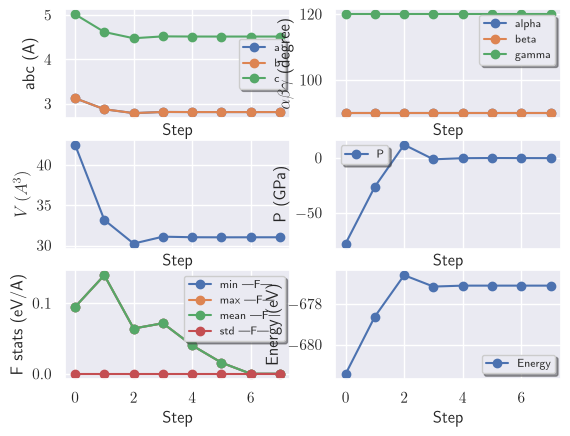

Initial lattice (a, b, c): (3.1285881400252173, 3.1285881399953857, 5.01695500001488)
Relaxed lattice (a, b, c): (2.816385890957495, 2.8163858909306403, 4.516312357272018)


In [11]:
with abilab.abiopen("flow_aln_relax/w0/t0/outdata/out_HIST.nc") as hist:
    hist.plot()
    print("Initial lattice (a, b, c):", hist.initial_structure.lattice.abc)
    print("Relaxed lattice (a, b, c):", hist.final_structure.lattice.abc)

`HistFile.plot()` above already includes a "forces" panel (min/max/mean/std
`|F|` per step). Since `tolmxf` is specifically a *max*-force criterion,
let's isolate that one number, step by step -- there's no `workshop_lib`
plotting function for this yet, so here it is directly from the reader:


In [15]:
with abilab.abiopen("flow_aln_relax/w0/t0/outdata/out_HIST.nc") as hist:
    forces = hist.reader.read_cart_forces()  # shape (nsteps, natom, 3), eV/Ang
    fmax_per_step = np.linalg.norm(forces, axis=2).max(axis=1)

for step, fmax in enumerate(fmax_per_step):
    print(f"step {step}: max |F| = {fmax:.2e} eV/Ang")

step 0: max |F| = 9.49e-02 eV/Ang
step 1: max |F| = 1.40e-01 eV/Ang
step 2: max |F| = 6.44e-02 eV/Ang
step 3: max |F| = 7.19e-02 eV/Ang
step 4: max |F| = 4.05e-02 eV/Ang
step 5: max |F| = 1.61e-02 eV/Ang
step 6: max |F| = 3.92e-04 eV/Ang
step 7: max |F| = 3.63e-04 eV/Ang


`HistFile` records the whole relaxation trajectory (energy, forces,
stress and the structure itself, at every ionic step) --
`.initial_structure`/`.final_structure` give direct access to the
endpoints. There's no `workshop_lib` function for what comes next --
`../Examples/save_aln_structure.py` is a plain post-processing script, not
a flow builder -- but here's what it does: grab the *final* relaxed
structure from the task's `GSR` file:


In [14]:
flow = flowtk.Flow.from_file("flow_aln_relax")
task = flow[0][0]                         # the only task of the only Work
gsr_path = task.outdir.has_abiext("GSR")   # retrieve the output GSR file

with abilab.abiopen(gsr_path) as gsr:
    relaxed_structure = gsr.structure

print(relaxed_structure)

Full Formula (Al2 N2)
Reduced Formula: AlN
abc   :   2.816386   2.816386   4.516312
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (4)
  #  SP           a         b         c  cartesian_forces
---  ----  --------  --------  --------  -----------------------------------------------------------
  0  Al    0.666667  0.333333  0.498386  [2.72795722e-21 1.57498684e-21 3.62835522e-04] eV ang^-1
  1  Al    0.333333  0.666667  0.998386  [-2.72795722e-21  4.72496051e-21  3.62835522e-04] eV ang^-1
  2  N     0.666667  0.333333  0.881614  [ 5.45591444e-21  0.00000000e+00 -3.62835522e-04] eV ang^-1
  3  N     0.333333  0.666667  0.381614  [-5.45591444e-21 -6.29994735e-21 -3.62835522e-04] eV ang^-1

Abinit Spacegroup: spgid: 186, num_spatial_symmetries: 12, has_timerev: True, symmorphic: True


The example script `save_aln_structure.py` does exactly this, 
then writes the relaxed structure to a standalone `.cif`
-- ready to be loaded back with `abilab.Structure.from_file(...)` and reused as the
input structure of a later calculation (e.g. a band structure or phonon
flow at the relaxed volume, instead of the experimental one).


# Exercise

Blob


# Next
Continue with [`4-Phonons.ipynb`](4-Phonons.ipynb).